# CS485 Homework 2: MLP Training - Model Analysis

* **Author:** Petrakidis Paschalis

* **AM:** CSD5487


## Part 0: HW1 Transition & Data Setup

**Random Seed:** `42`

This section establishes the data pipeline, carrying forward the SDSS dataset used in Homework 1 - using the Photometric and Spectral features to predict the continuous Redshift target.

The below code imports all the necessary libraries for computing and plotting the results, splits and normalizes the data for later use.

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

#load csv dataset saved from HW1
df = pd.read_csv('sdss_data.csv')

#define features (X) and target (y) based on HW1
features = [
    'SPECTROFLUX_U', 
    'SPECTROFLUX_G', 
    'SPECTROFLUX_R', 
    'SPECTROFLUX_I', 
    'SPECTROFLUX_Z', 
    'VDISP'
]
#filter dataframe to include features and target only, then split
clean_df = df[features + ['Z']].dropna()
X = clean_df[features].values
y = clean_df['Z'].values

#70% Train, 30% Temporary - then split Temporary into 15% Validation and 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.30, random_state = RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.50, random_state = RANDOM_SEED)

print(f"Training set: {X_train.shape[0]} samples (70%)")
print(f"Validation set: {X_val.shape[0]} samples (15%)")
print(f"Test set: {X_test.shape[0]} samples (15%)")

#normalise the features, fitting only on trained data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Training set: 700 samples (70%)
Validation set: 150 samples (15%)
Test set: 150 samples (15%)


**Observations and Comments (3.1): Information Leakage**
It is incorrect to fit the StandardScaler on the full dataset before splitting because it causes data leakage. If the scaler sees the entire dataset, including the mean and variance used to scale the training data, it will be influenced by the extreme values of the validation and test sets. This leads to artificially inflated performance metrics.

**Observations and Comments (3.2): HW1 Insight**
* **Finding:** In Homework 1, the EDA and regression analysis revealed that the relationship between photometric flux (like `SPECTROFLUX_R`) and Redshift ($Z$) is highly non-linear, showing an L-shape.
As a result, the Multivariate Linear Regression model failed to capture the variance (scoring a $R^2$ of ~0.02) and the resulting residuals were non-Gaussian.
* **Motivation:** This finding motivates the transition to a Multi-Layer Perceptron. Unlike linear models, an MLP utilizes hidden layers and non-linear activation functions to map complex relationships in the feature space. This architecture should improve the ~0.02 $R^2$ baseline and produce residuals that show a better approximation of a standard normal distribution.

## Part 1: Baseline MLP - Architecture & Training

### 4.1 Architecture Definition
The Multi-Layer Perceptron will be constructed using PyTorch. To prepare the data for PyTorch, the scaled NumPy arrays must be converted into PyTorch Tensors and wrap the training data in a `DataLoader` for batch processing.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

#convert NumPy arrays to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_t = torch.tensor(y_train, dtype = torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype = torch.float32)
y_val_t = torch.tensor(y_val, dtype = torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_t = torch.tensor(y_test, dtype = torch.float32).view(-1, 1)

#create dataLoader for batching
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)

#define the MLP architecture
class BaselineMLP(nn.Module):
    def __init__(self, input_dim):
        super(BaselineMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),  # Hidden Layer 1
            nn.ReLU(),                 # Activation 1
            nn.Linear(64, 32),         # Hidden Layer 2
            nn.ReLU(),                 # Activation 2
            nn.Linear(32, 1)           # Output Layer
        )

    def forward(self, x):
        return self.layers(x)

#instantiate the model - there are 6 input features
input_dim = X_train_scaled.shape[1]
model = BaselineMLP(input_dim)

#compute total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Baseline MLP instantiated with {total_params} trainable parameters.")

Baseline MLP instantiated with 2561 trainable parameters.


**Discussion 4.1: Architecture Choices**
* **Structure:** The model consists of 2 hidden layers (64 and 32 neurons respectively) and a total of 2,561 trainable parameters.
* **Justification (Depth/Width):** Two hidden layers are sufficient to approximate the majority of continuous non-linear functions without overfitting. The funnel (64 $\rightarrow$ 32) forces the network to compress the 6 multimodal features into a dense representation before outputting the final prediction.
* **Activation:** ReLU is used as it is computationally efficient and prevents vanishing gradients. The output layer uses *no* activation function (linear output), which is required for standard unbounded continuous regression.

### 4.2 Training Loop
The network is trained using standard Stochastic Gradient Descent (SGD) to minimize the Mean Squared Error (MSE) loss function. Both training and validation loss are recorded at every epoch to monitor convergence and check for overfitting.

Starting Training...
Training complete


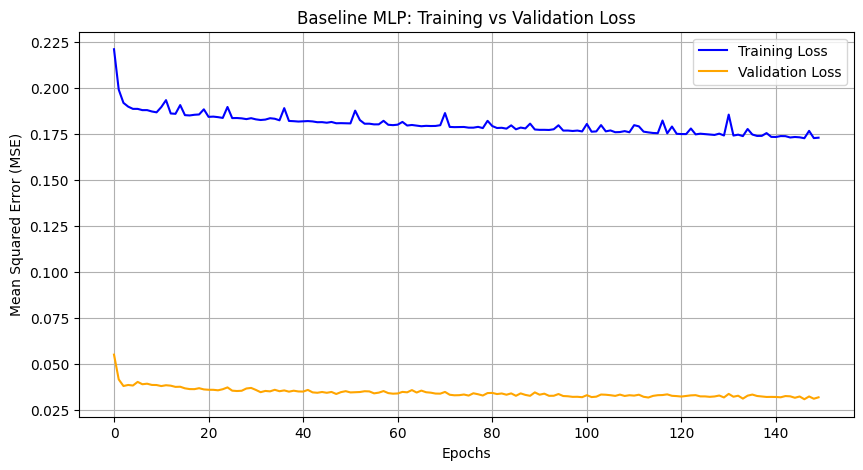

In [6]:
#soss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

epochs = 150
train_losses = []
val_losses = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    batch_losses = []
    
    #training pass
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    avg_train_loss = np.mean(batch_losses)
    train_losses.append(avg_train_loss)
    
    #validation pass
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_losses.append(val_loss)

print("Training complete")
#plotting loss curves
plt.figure(figsize = (10, 5))
plt.plot(train_losses, label = 'Training Loss', color = 'blue')
plt.plot(val_losses, label = 'Validation Loss', color = 'orange')
plt.title('Baseline MLP: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Observations and Comments 4.2: Convergence and Divergence**

* **Convergence:** The model demonstrates rapid and appropriate convergence. The steep drop in MSE occurs within the first 20 to 30 epochs, after which both the training and validation curves flatten into a stable graph. This indicates that the network quickly learned the primary non-linear patterns in the dataset and reached an optimal state.
* **Divergence:** The two curves do *not* diverge at any point. The validation loss (orange) closely reflects the training loss (blue) and remains consistently flat over later epochs.
* **What divergence indicates:** Because the curves stay tightly related and flat, the baseline MLP is generalizing well without overfitting (the validation curve (orange) stays flat at the end, not curving upwards - which would indicate overfitting - and results in the model attempting to memorize statistical noise of training data instead of learning general patterns).

### 4.3 Evaluation & Comparison
Next follows the evaluation of the fully trained MLP on the completely unseen Test set and comparison to the baseline results achieved in Homework 1.

,Model,Test MSE,Test R^2
0,Multivariate Linear Regression (HW1),0.150900,0.022400
1,Baseline MLP (HW2),0.065745,0.194367


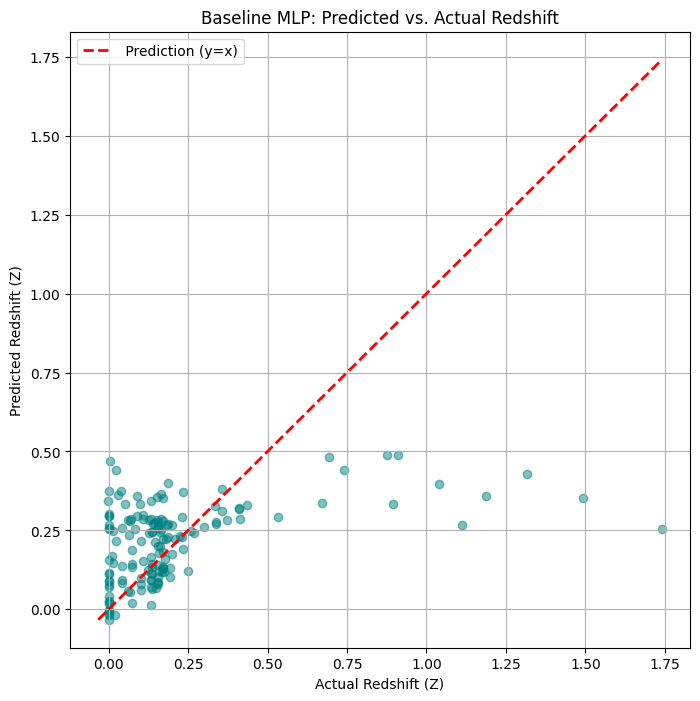

In [7]:
#predict based on the test set
model.eval()
with torch.no_grad():
    y_test_pred_t = model(X_test_t)
    #convert tensor back to numpy array for sklearn metrics and plotting
    y_test_pred = y_test_pred_t.numpy().flatten()

#calculate test metrics
mlp_mse = mean_squared_error(y_test, y_test_pred)
mlp_r2 = r2_score(y_test, y_test_pred)

#create the comparison table
comparison_data = {
    "Model": ["Multivariate Linear Regression (HW1)", "Baseline MLP (HW2)"],
    "Test MSE": [0.1509, mlp_mse],  #hw1 baseline
    "Test R^2": [0.0224, mlp_r2]
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

#predicted vs actual scatter
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_test_pred, alpha = 0.5, color = 'teal')

#plot a prediction diagonal line (y = x)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2, label = ' Prediction (y=x)')
plt.title('Baseline MLP: Predicted vs. Actual Redshift')
plt.xlabel('Actual Redshift (Z)')
plt.ylabel('Predicted Redshift (Z)')
plt.legend()
plt.grid(True)
plt.show()

Along larger redshift values, the scatter plots dont follow the pefect diagonal curve. That is because higher redshift value objects are very rare leading to the MLP not having enough training data to correctly predict them accurately.
Overall, the model output on the test is successful, looking at the clustered dots along the more common redshift values which it predicts well.